# 🏥 US Healthcare Medicare Analytics & Data Science Master Project
## *From Basic Data Analysis & SQL Foundations to Intermediate Relational Warehousing, Statistics & Machine Learning*

---

## 🎯 Course & Project Roadmap (Basic to Intermediate/Advanced)

This notebook is meticulously structured to serve as an end-to-end data analytics curriculum and portfolio project using real-world CMS (Centers for Medicare & Medicaid Services) Home Health Agency (HHA) data:

```
┌────────────────────────────────────────────────────────────────────────────────────────┐
│ 🟢 LEVEL 1: BASIC DATA ANALYST TRACK                                                    │
├────────────────────────────────────────────────────────────────────────────────────────┤
│ 1.1 Environment Setup & Library Foundations (pandas, numpy, sqlite3, matplotlib)       │
│ 1.2 Data Ingestion & Exploratory Inspection (.head, .info, .describe, .shape)         │
│ 1.3 Basic Data Filtering, Slicing & Subsetting (Conditions, Boolean Masking, Sorting)   │
│ 1.4 Basic Aggregations in Pandas (groupby, count, sum, mean, agg)                       │
│ 1.5 Foundational SQL (SELECT, WHERE, ORDER BY, LIMIT, GROUP BY, HAVING, basic JOINs)    │
│ 1.6 Basic Visualizations (Single Bar Chart, Histogram, Boxplot)                        │
└────────────────────────────────────────────────────────────────────────────────────────┘
                                           │
                                           ▼
┌────────────────────────────────────────────────────────────────────────────────────────┐
│ 🟡 LEVEL 2: INTERMEDIATE DATA ANALYST TRACK                                             │
├────────────────────────────────────────────────────────────────────────────────────────┤
│ 2.1 Healthcare Domain Knowledge (LUPA, HCC Risk, PPS, Dual Eligibility, Wage Index)    │
│ 2.2 Data Cleaning, Privacy Suppression (<11) Imputation & Feature Engineering          │
│ 2.3 Relational Data Warehousing & Star Schema (DDL, Foreign Keys, Fact & Dim Tables)   │
│ 2.4 Intermediate SQL BI (CTEs, Window Functions: RANK, NTILE, PERCENT_RANK, Overviews) │
│ 2.5 Multi-Panel & Advanced Visualizations (Dual-Axis, Stacked Bars, Correlation Heatmap)│
│ 2.6 Inferential Statistics & Hypothesis Testing (Welch's t-test, Kruskal-Wallis, ANOVA) │
└────────────────────────────────────────────────────────────────────────────────────────┘
                                           │
                                           ▼
┌────────────────────────────────────────────────────────────────────────────────────────┐
│ 🔴 LEVEL 3: INTERMEDIATE-TO-ADVANCED DATA SCIENCE & STRATEGY                           │
├────────────────────────────────────────────────────────────────────────────────────────┤
│ 3.1 Multi-Variable OLS Linear Regression for Reimbursement Forecasting                 │
│ 3.2 Unsupervised Machine Learning: K-Means Provider Practice Archetype Clustering     │
│ 3.3 Principal Component Analysis (PCA) 2D Projection                                   │
│ 3.4 Outlier & Fraud Screening with Isolation Forest                                    │
│ 3.5 Executive KPI Scorecard & Strategic Recommendations for Healthcare Leaders         │
└────────────────────────────────────────────────────────────────────────────────────────┘
```


---
# 🟢 LEVEL 1: BASIC DATA ANALYST TRACK
*Foundations of Python, Pandas, Basic Filtering, Aggregations, Fundamental SQL & Simple Charts*
---


### 1.1 Environment Setup & Library Foundations
We begin by importing the core Python libraries used by every Data Analyst: `pandas` for data manipulation, `numpy` for numerical operations, `sqlite3` for SQL databases, and `matplotlib` / `seaborn` for plotting.


In [1]:
import os
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Suppress minor warnings for clean output
warnings.filterwarnings('ignore')

# Configure Pandas display options for easy table viewing
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}' if abs(x) >= 0.01 else f'{x:,.4f}')

# Configure clean chart styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

print("✅ Step 1.1 Complete: Environment and Libraries loaded successfully!")


✅ Step 1.1 Complete: Environment and Libraries loaded successfully!


### 1.2 Data Ingestion & Basic Inspection
As a data analyst, the first step is always inspecting the structure of the raw file: checking row and column counts, viewing the first few records, and checking data types.


In [2]:
# 1. Load the dataset from CSV
DATA_PATH = os.path.abspath('data/us_healthcare_hha_data.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.abspath('../data/us_healthcare_hha_data.csv') if os.path.exists('../data/us_healthcare_hha_data.csv') else 'us_healthcare_hha_data.csv'

raw_df = pd.read_csv(DATA_PATH)

# 2. Basic dataset properties
print(f"📊 Dataset Shape: {raw_df.shape[0]} rows (agencies) by {raw_df.shape[1]} columns (features)")
print("-" * 80)
print("🔍 First 5 rows of the dataset:")
display(raw_df.head(5))

print("-" * 80)
print("📋 Concise DataFrame Info (Column Types & Non-Null Counts):")
raw_df.info(verbose=False)


📊 Dataset Shape: 82 rows (agencies) by 49 columns (features)
--------------------------------------------------------------------------------
🔍 First 5 rows of the dataset:


,provider_id,agency_name,street_address,city,state,zip_code,total_episodes_non_lupa,distinct_beneficiaries_non_lupa,average_number_of_total_visits_per_episode_non_lupa,average_number_of_skilled_nursing_visits_per_episode_non_lupa,average_number_of_pt_visits_per_episode_non_lupa,average_number_of_ot_visits_per_episode_non_lupa,average_number_of_st_visits_per_episode_non_lupa,average_number_of_home_health_aide_visits_per_episode_non_lupa,average_number_of_medical_social_visits_per_episode_non_lupa,total_hha_charge_amount_non_lupa,total_hha_medicare_payment_amount_non_lupa,total_hha_medicare_standard_payment_amount_non_lupa,outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa,total_lupa_episodes,total_hha_medicare_payment_amount_for_lupas,average_age,male_beneficiaries,female_beneficiaries,nondual_beneficiaries,dua_beneficiaries,white_beneficiaries,black_beneficiaries,asian_pacific_islander_beneficiaries,hispanic_beneficiaries,american_indian_or_alaska_native_beneficiaries,other_unknown_beneficiaries,average_hcc_score,percent_of_beneficiaries_with_atrial_fibrillation,percent_of_beneficiaries_with_alzheimers,percent_of_beneficiaries_with_asthma,percent_of_beneficiaries_with_cancer,percent_of_beneficiaries_with_chf,percent_of_beneficiaries_with_chronic_kidney_disease,percent_of_beneficiaries_with_copd,percent_of_beneficiaries_with_depression,percent_of_beneficiaries_with_diabetes,percent_of_beneficiaries_with_hyperlipidemia,percent_of_beneficiaries_with_hypertension,percent_of_beneficiaries_with_ihd,percent_of_beneficiaries_with_osteoporosis,percent_of_beneficiaries_with_ra_oa,percent_of_beneficiaries_with_schizophrenia,percent_of_beneficiaries_with_stroke
0,58330,"DIVINE HOME HEALTH, INC",14625 CARMENITA ROAD SUITE 228,NORWALK,CA,90650,681,486,13.40,9.80,2.70,0.10,0.0000,0.80,0.0000,1368276,2217148,1787361,6.50,31,12912,80,139,347,55,431,35.00,NaN,407,26.00,NaN,17.00,2.00,9,39,15,8,30,39,16,21,74.00,70.00,NaN,57.00,44,72.00,4,8
1,58376,"ORANGE COUNTY CARE PROVIDERS, INC",14700 E FIRESTONE BLVD SUITE 128,LA MIRADA,CA,90638,614,293,18.00,12.80,4.30,0.10,0.10,0.70,0.0000,1652285,2137998,1747600,6.20,44,16321,82,97,196,92,201,189.00,NaN,63,NaN,NaN,28.00,2.74,24,46,19,16,45,51,37,49,49.00,72.00,NaN,54.00,19,67.00,7,12
2,147844,"ALERT HOME HEALTH CARE, INC","8118 N MILWAUKEE AVENUE, STE 109",NILES,IL,60714,501,197,10.40,7.50,1.50,0.10,0.0000,1.30,0.0000,669226,1189842,1165889,0.0000,43,11642,79,58,139,81,116,149.00,NaN,17,NaN,NaN,13.00,2.16,23,27,20,9,52,32,28,39,68.00,73.00,NaN,68.00,23,NaN,3,10
3,227290,"SUBURBAN HOME HEALTH CARE, INC",1050 COMMONWEALTH AVE,BOSTON,MA,2115,1466,696,31.90,17.20,4.60,0.50,0.20,9.50,0.0000,5856605,5549658,4418284,8.80,58,23848,82,203,493,117,579,476.00,31.00,108,NaN,NaN,71.00,2.25,28,33,14,14,48,49,16,40,54.00,64.00,NaN,63.00,16,62.00,10,7
4,747139,KOREAN HOME HEALTH,1908 ROYAL LANE SUITE 100,DALLAS,TX,75229,1691,419,15.00,8.30,1.80,0.10,0.0000,4.70,0.0000,3811831,3725304,3914596,0.0000,24,8595,78,146,273,75,344,NaN,NaN,384,NaN,NaN,17.00,1.50,6,31,12,4,28,31,16,16,53.00,NaN,NaN,33.00,35,74.00,2,6


--------------------------------------------------------------------------------
📋 Concise DataFrame Info (Column Types & Non-Null Counts):
<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Columns: 49 entries, provider_id to percent_of_beneficiaries_with_stroke
dtypes: float64(19), int64(26), str(4)
memory usage: 36.7 KB


### 1.3 Basic Data Filtering, Slicing & Sorting
Here we demonstrate essential analyst operations:
1. **Filtering by single condition** (e.g. agencies in California `state == 'CA'`).
2. **Filtering by multiple conditions** (e.g. agencies with more than 1,000 episodes AND Medicare payments over $2,000,000).
3. **Sorting values** ascending and descending.


In [3]:
# Basic Filter 1: Single Condition (Agencies in California)
ca_agencies = raw_df[raw_df['state'] == 'CA']
print(f"Total California Agencies: {len(ca_agencies)}")
display(ca_agencies[['provider_id', 'agency_name', 'city', 'state', 'total_episodes_non_lupa']].head(3))

# Basic Filter 2: Multiple Conditions (High Volume & High Payment Agencies)
high_volume_pmt = raw_df[
    (raw_df['total_episodes_non_lupa'] > 1000) & 
    (raw_df['total_hha_medicare_payment_amount_non_lupa'] > 2000000)
]
print(f"\nHigh-Volume High-Payment Agencies (>1000 episodes & >$2M payment): {len(high_volume_pmt)}")
display(high_volume_pmt[['agency_name', 'state', 'total_episodes_non_lupa', 'total_hha_medicare_payment_amount_non_lupa']].sort_values(by='total_hha_medicare_payment_amount_non_lupa', ascending=False).head(5))


Total California Agencies: 14


,provider_id,agency_name,city,state,total_episodes_non_lupa
0,58330,"DIVINE HOME HEALTH, INC",NORWALK,CA,681
1,58376,"ORANGE COUNTY CARE PROVIDERS, INC",LA MIRADA,CA,614
5,58247,BLUE STAR HOME HEALTH INC,CHATSWORTH,CA,544



High-Volume High-Payment Agencies (>1000 episodes & >$2M payment): 32


,agency_name,state,total_episodes_non_lupa,total_hha_medicare_payment_amount_non_lupa
42,VNA OF BOSTON,MA,7127,24386328
76,SOUTHEASTERN HEALTH SERVICES OF PA,PA,3880,15586295
18,NURSE ON CALL,FL,4029,13721501
59,INOVA VNA HOME HEALTH,VA,4464,13227259
46,"AMERICARE CERTIFIED SPECIAL SERVICES, INC CHHA",NY,3083,12999949


### 1.4 Basic Aggregations with Pandas `groupby()`
Data analysts constantly summarize metrics across categories. Here we calculate basic aggregations (Count, Sum, Mean, Min, Max) of Medicare payments and episodes by State.


In [4]:
# Basic GroupBy: State-level episode and payment metrics
basic_state_summary = raw_df.groupby('state').agg(
    total_agencies=('provider_id', 'count'),
    total_episodes=('total_episodes_non_lupa', 'sum'),
    total_medicare_payments=('total_hha_medicare_payment_amount_non_lupa', 'sum'),
    avg_payment_per_agency=('total_hha_medicare_payment_amount_non_lupa', 'mean'),
    avg_visits_per_episode=('average_number_of_total_visits_per_episode_non_lupa', 'mean')
).sort_values(by='total_medicare_payments', ascending=False)

print("📊 Basic State Summary Table:")
display(basic_state_summary)


📊 Basic State Summary Table:


,total_agencies,total_episodes,total_medicare_payments,avg_payment_per_agency,avg_visits_per_episode
state,,,,,
IL,26,26152,79936214,"3,074,469.77",14.83
VA,12,16072,54381272,"4,531,772.67",18.17
FL,5,10067,31954961,"6,390,992.20",19.68
PA,4,8914,31551540,"7,887,885.00",21.55
MA,2,8593,29935986,"14,967,993.00",23.85
TX,11,9340,25619077,"2,329,007.00",16.31
CA,14,7537,24676398,"1,762,599.86",15.65
MD,2,4817,15188414,"7,594,207.00",14.95
NY,3,3630,14914329,"4,971,443.00",24.57


### 1.5 Foundational SQL (Basic Queries)
Before exploring advanced SQL window functions and CTEs, every analyst must master foundational SQL queries:
1. `SELECT ... WHERE ... ORDER BY ... LIMIT`
2. `GROUP BY ... HAVING ...`
3. Basic `INNER JOIN` across tables.


In [5]:
# Create in-memory SQLite database for basic SQL demonstration
temp_conn = sqlite3.connect(':memory:')
raw_df.to_sql('raw_providers', temp_conn, index=False)

# SQL Query 1: Basic SELECT, WHERE, ORDER BY, LIMIT
sql_basic_1 = """
SELECT 
    provider_id,
    agency_name,
    city,
    state,
    total_episodes_non_lupa,
    total_hha_medicare_payment_amount_non_lupa
FROM raw_providers
WHERE state = 'TX' AND total_episodes_non_lupa >= 500
ORDER BY total_episodes_non_lupa DESC
LIMIT 5;
"""
print("🔹 Basic SQL Query 1: Top Texas Agencies with >= 500 episodes")
display(pd.read_sql_query(sql_basic_1, temp_conn))

# SQL Query 2: Basic GROUP BY and HAVING
sql_basic_2 = """
SELECT 
    state,
    COUNT(provider_id) AS agency_count,
    SUM(total_episodes_non_lupa) AS total_episodes,
    SUM(total_hha_medicare_payment_amount_non_lupa) AS total_medicare_payments
FROM raw_providers
GROUP BY state
HAVING COUNT(provider_id) >= 4
ORDER BY total_medicare_payments DESC;
"""
print("\n🔹 Basic SQL Query 2: Aggregated States with at least 4 agencies (HAVING)")
display(pd.read_sql_query(sql_basic_2, temp_conn))


🔹 Basic SQL Query 1: Top Texas Agencies with >= 500 episodes


,provider_id,agency_name,city,state,total_episodes_non_lupa,total_hha_medicare_payment_amount_non_lupa
0,457222,GIRLING HOME HEALTH TEXAS BY HARDEN HEALTHCARE,BELLAIRE,TX,1846,5945846
1,747139,KOREAN HOME HEALTH,DALLAS,TX,1691,3725304
2,743191,LUCENT HOME HEALTH LLC,RICHARDSON,TX,1350,3044280
3,679407,THERACARE HOME HEALTH,LEWISVILLE,TX,891,3371405
4,679749,THE PROVIDENCE HOME HEALTH SERVICES INC,SUGAR LAND,TX,810,2212033



🔹 Basic SQL Query 2: Aggregated States with at least 4 agencies (HAVING)


,state,agency_count,total_episodes,total_medicare_payments
0,IL,26,26152,79936214
1,VA,12,16072,54381272
2,FL,5,10067,31954961
3,PA,4,8914,31551540
4,TX,11,9340,25619077
5,CA,14,7537,24676398


### 1.6 Basic Visualizations (Level 1)
Simple, clean visual summaries:
1. **Bar Chart:** Number of Certified Agencies by State.
2. **Histogram:** Distribution of Average Beneficiary Age.
3. **Boxplot:** Patient HCC Risk Scores across major states.


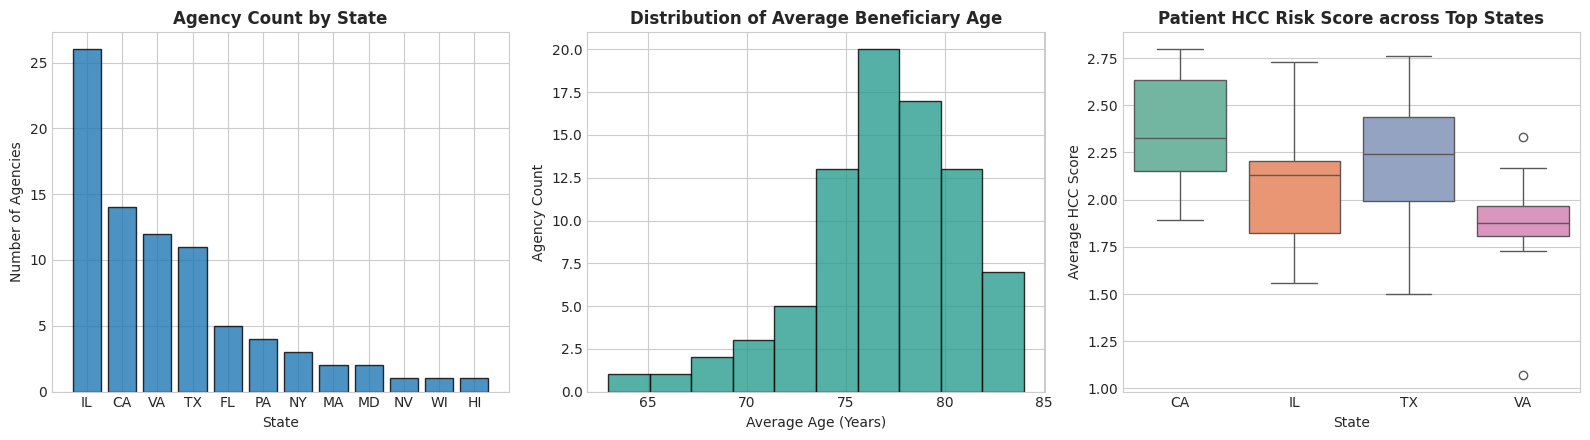

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Bar chart: Agency count by state
state_counts = raw_df['state'].value_counts()
axes[0].bar(state_counts.index, state_counts.values, color='#1f77b4', edgecolor='black', alpha=0.8)
axes[0].set_title('Agency Count by State', fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Number of Agencies')

# 2. Histogram: Average Beneficiary Age
axes[1].hist(raw_df['average_age'], bins=10, color='#2a9d8f', edgecolor='black', alpha=0.8)
axes[1].set_title('Distribution of Average Beneficiary Age', fontweight='bold')
axes[1].set_xlabel('Average Age (Years)')
axes[1].set_ylabel('Agency Count')

# 3. Boxplot: HCC Risk Score across Top 4 States
top_states = raw_df['state'].value_counts().head(4).index
sns.boxplot(data=raw_df[raw_df['state'].isin(top_states)], x='state', y='average_hcc_score', palette='Set2', ax=axes[2])
axes[2].set_title('Patient HCC Risk Score across Top States', fontweight='bold')
axes[2].set_xlabel('State')
axes[2].set_ylabel('Average HCC Score')

plt.tight_layout()
plt.show()


---
# 🟡 LEVEL 2: INTERMEDIATE DATA ANALYST TRACK
*Healthcare Domain Modeling, Missing Value Imputation, Star Schema Data Warehousing, Advanced SQL (CTEs, Window Functions) & Hypothesis Testing*
---


### 2.1 Healthcare Domain Primer & Metrics Glossary
To perform intermediate and advanced analytics, a data analyst must understand the business rules of the healthcare industry:
* **Non-LUPA Episodes:** Standard care episodes where visit volume satisfies full Medicare Prospective Payment System (PPS) reimbursement.
* **LUPA (Low Utilization Payment Adjustment):** Episodes with 4 or fewer visits. Reimbursed on a lower per-visit rate rather than a full episode rate. High LUPA rates signal potential operational inefficiency or premature patient discharge.
* **HCC (Hierarchical Condition Category) Risk Score:** Calibrated at $1.0$ as national average. A score of $2.2$ indicates patients are predicted to require $120\%$ more healthcare resources due to comorbid illness (CHF, COPD, CKD, Diabetes).
* **Dual-Eligible Beneficiaries:** Patients qualifying for both Medicare (age/disability) and Medicaid (low income). This serves as a vital proxy for social determinants of health (SDOH).
* **Standardized vs. Actual Medicare Payment:** Standardized payments remove geographic wage index variations, enabling fair comparison of payment rates across states.


### 2.2 Data Cleaning, Privacy Suppression (<11) Imputation & Feature Engineering
We now implement an enterprise-grade data transformation pipeline:
1. **CMS Privacy Suppression Imputation:** Imputing missing demographic counts (<11 beneficiaries) with `0.0`.
2. **Clinical Comorbidity Imputation:** Filling unrecorded chronic disease prevalences with the population median.
3. **Feature Engineering:**
   * `pct_female` & `pct_dual_eligible`
   * `payment_per_episode` & `standard_payment_per_episode`
   * `payment_to_charge_ratio` & `charge_to_payment_markup`
   * `payment_variance` (Actual - Standardized Payment = Wage Index Impact)
   * `lupa_episode_rate` & `payment_per_lupa_episode`
   * `hcc_risk_tier` (Categorical risk stratification)
   * Discipline visit shares (`pct_skilled_nursing_visits`, `pct_pt_visits`, `pct_aide_visits`, `pct_therapy_visits_combined`)


In [7]:
# Clean column names to lowercase snake_case
df = raw_df.copy()
df.columns = [c.strip().lower() for c in df.columns]

# 1. Demographic privacy suppression handling
demo_cols = [
    'white_beneficiaries', 'black_beneficiaries', 
    'asian_pacific_islander_beneficiaries', 'hispanic_beneficiaries', 
    'american_indian_or_alaska_native_beneficiaries', 'other_unknown_beneficiaries'
]
for col in demo_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0.0).astype(float)

# 2. Clinical condition median imputation
clinical_cols = [
    'percent_of_beneficiaries_with_atrial_fibrillation', 'percent_of_beneficiaries_with_alzheimers',
    'percent_of_beneficiaries_with_asthma', 'percent_of_beneficiaries_with_cancer',
    'percent_of_beneficiaries_with_chf', 'percent_of_beneficiaries_with_chronic_kidney_disease',
    'percent_of_beneficiaries_with_copd', 'percent_of_beneficiaries_with_depression',
    'percent_of_beneficiaries_with_diabetes', 'percent_of_beneficiaries_with_hyperlipidemia',
    'percent_of_beneficiaries_with_hypertension', 'percent_of_beneficiaries_with_ihd',
    'percent_of_beneficiaries_with_osteoporosis', 'percent_of_beneficiaries_with_ra_oa',
    'percent_of_beneficiaries_with_schizophrenia', 'percent_of_beneficiaries_with_stroke'
]
for col in clinical_cols:
    if col in df.columns:
        med = df[col].median()
        df[col] = df[col].fillna(med if not pd.isna(med) else 0.0)

# 3. Demographic & Utilization Feature Engineering
total_gender = df['male_beneficiaries'] + df['female_beneficiaries']
df['pct_female'] = np.where(total_gender > 0, (df['female_beneficiaries'] / total_gender) * 100.0, 0.0)

total_dual = df['nondual_beneficiaries'] + df['dua_beneficiaries']
df['pct_dual_eligible'] = np.where(total_dual > 0, (df['dua_beneficiaries'] / total_dual) * 100.0, 0.0)

df['episodes_per_beneficiary'] = np.where(
    df['distinct_beneficiaries_non_lupa'] > 0,
    df['total_episodes_non_lupa'] / df['distinct_beneficiaries_non_lupa'],
    1.0
)

# 4. Financial & Reimbursement Metrics
df['payment_to_charge_ratio'] = np.where(
    df['total_hha_charge_amount_non_lupa'] > 0,
    df['total_hha_medicare_payment_amount_non_lupa'] / df['total_hha_charge_amount_non_lupa'],
    0.0
)
df['charge_to_payment_markup'] = np.where(
    df['total_hha_medicare_payment_amount_non_lupa'] > 0,
    df['total_hha_charge_amount_non_lupa'] / df['total_hha_medicare_payment_amount_non_lupa'],
    0.0
)
df['payment_per_episode'] = np.where(
    df['total_episodes_non_lupa'] > 0,
    df['total_hha_medicare_payment_amount_non_lupa'] / df['total_episodes_non_lupa'],
    0.0
)
df['standard_payment_per_episode'] = np.where(
    df['total_episodes_non_lupa'] > 0,
    df['total_hha_medicare_standard_payment_amount_non_lupa'] / df['total_episodes_non_lupa'],
    0.0
)
df['payment_variance'] = df['payment_per_episode'] - df['standard_payment_per_episode']

total_all_episodes = df['total_episodes_non_lupa'] + df['total_lupa_episodes']
df['lupa_episode_rate'] = np.where(
    total_all_episodes > 0,
    (df['total_lupa_episodes'] / total_all_episodes) * 100.0,
    0.0
)
df['payment_per_lupa_episode'] = np.where(
    df['total_lupa_episodes'] > 0,
    df['total_hha_medicare_payment_amount_for_lupas'] / df['total_lupa_episodes'],
    0.0
)

# 5. Clinical Risk Tier Stratification
risk_conditions = [
    (df['average_hcc_score'] < 1.80),
    (df['average_hcc_score'] >= 1.80) & (df['average_hcc_score'] <= 2.40),
    (df['average_hcc_score'] > 2.40)
]
risk_labels = ['Tier 1: Low Risk (<1.80)', 'Tier 2: Moderate Risk (1.80-2.40)', 'Tier 3: High Acuity (>2.40)']
df['hcc_risk_tier'] = np.select(risk_conditions, risk_labels, default='Tier 2: Moderate Risk (1.80-2.40)')

# 6. Discipline Visit Percentages
tot_vis = df['average_number_of_total_visits_per_episode_non_lupa']
df['pct_skilled_nursing_visits'] = np.where(tot_vis > 0, (df['average_number_of_skilled_nursing_visits_per_episode_non_lupa'] / tot_vis) * 100.0, 0.0)
df['pct_pt_visits'] = np.where(tot_vis > 0, (df['average_number_of_pt_visits_per_episode_non_lupa'] / tot_vis) * 100.0, 0.0)
df['pct_ot_visits'] = np.where(tot_vis > 0, (df['average_number_of_ot_visits_per_episode_non_lupa'] / tot_vis) * 100.0, 0.0)
df['pct_st_visits'] = np.where(tot_vis > 0, (df['average_number_of_st_visits_per_episode_non_lupa'] / tot_vis) * 100.0, 0.0)
df['pct_aide_visits'] = np.where(tot_vis > 0, (df['average_number_of_home_health_aide_visits_per_episode_non_lupa'] / tot_vis) * 100.0, 0.0)
df['pct_therapy_visits_combined'] = df['pct_pt_visits'] + df['pct_ot_visits'] + df['pct_st_visits']

# 7. Census Region Mapping
region_map = {
    'MA': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'WI': 'Midwest',
    'FL': 'South', 'MD': 'South', 'VA': 'South', 'TX': 'South',
    'CA': 'West', 'NV': 'West', 'HI': 'West'
}
df['region'] = df['state'].map(region_map).fillna('Other')

print("✅ Step 2.2 Complete: Data Cleaning and Feature Engineering finished successfully!")
display(df[['provider_id', 'agency_name', 'state', 'hcc_risk_tier', 'payment_per_episode', 'lupa_episode_rate', 'pct_therapy_visits_combined']].head(5))


✅ Step 2.2 Complete: Data Cleaning and Feature Engineering finished successfully!


,provider_id,agency_name,state,hcc_risk_tier,payment_per_episode,lupa_episode_rate,pct_therapy_visits_combined
0,58330,"DIVINE HOME HEALTH, INC",CA,Tier 2: Moderate Risk (1.80-2.40),"3,255.72",4.35,20.90
1,58376,"ORANGE COUNTY CARE PROVIDERS, INC",CA,Tier 3: High Acuity (>2.40),"3,482.08",6.69,25.00
2,147844,"ALERT HOME HEALTH CARE, INC",IL,Tier 2: Moderate Risk (1.80-2.40),"2,374.93",7.90,15.38
3,227290,"SUBURBAN HOME HEALTH CARE, INC",MA,Tier 2: Moderate Risk (1.80-2.40),"3,785.58",3.81,16.61
4,747139,KOREAN HOME HEALTH,TX,Tier 1: Low Risk (<1.80),"2,203.02",1.40,12.67


### 2.3 Star Schema Relational Data Warehousing (SQLite)
We model the cleaned dataset into a **Star Schema** with primary/foreign keys and performance indexes:
* **`dim_provider`**: Provider CMS ID, agency name, address, city, state, zip.
* **`dim_geography`**: Zip code, city, state, census region.
* **`dim_patient_demographics`**: Age, gender proportions, dual-eligibility rate.
* **`dim_clinical_conditions`**: HCC risk acuity score, risk tier, 16 chronic disease prevalences.
* **`fact_hha_episodes_financials`**: Episode counts, visits by discipline, billed charges, payments, outlier %.


In [8]:
# Initialize persistent SQLite Data Warehouse
DB_PATH = 'data/healthcare_warehouse.db'
conn = sqlite3.connect(DB_PATH)

# Populate Dimension & Fact Tables
dim_provider = df[['provider_id', 'agency_name', 'street_address', 'city', 'state', 'zip_code']].drop_duplicates()
dim_provider.to_sql('dim_provider', conn, if_exists='replace', index=False)

dim_geography = df[['zip_code', 'city', 'state', 'region']].drop_duplicates(subset=['zip_code'])
dim_geography.to_sql('dim_geography', conn, if_exists='replace', index=False)

dim_demo = df[[
    'provider_id', 'average_age', 'male_beneficiaries', 'female_beneficiaries', 'pct_female',
    'nondual_beneficiaries', 'dua_beneficiaries', 'pct_dual_eligible',
    'white_beneficiaries', 'black_beneficiaries', 'asian_pacific_islander_beneficiaries',
    'hispanic_beneficiaries', 'american_indian_or_alaska_native_beneficiaries', 'other_unknown_beneficiaries'
]].rename(columns={
    'dua_beneficiaries': 'dual_beneficiaries',
    'american_indian_or_alaska_native_beneficiaries': 'native_american_beneficiaries'
}).drop_duplicates(subset=['provider_id'])
dim_demo.to_sql('dim_patient_demographics', conn, if_exists='replace', index=False)

dim_clinical = df[[
    'provider_id', 'average_hcc_score', 'hcc_risk_tier',
    'percent_of_beneficiaries_with_chf', 'percent_of_beneficiaries_with_copd',
    'percent_of_beneficiaries_with_chronic_kidney_disease', 'percent_of_beneficiaries_with_diabetes',
    'percent_of_beneficiaries_with_hypertension', 'percent_of_beneficiaries_with_hyperlipidemia',
    'percent_of_beneficiaries_with_ihd', 'percent_of_beneficiaries_with_alzheimers',
    'percent_of_beneficiaries_with_depression', 'percent_of_beneficiaries_with_cancer',
    'percent_of_beneficiaries_with_stroke', 'percent_of_beneficiaries_with_atrial_fibrillation',
    'percent_of_beneficiaries_with_asthma', 'percent_of_beneficiaries_with_osteoporosis',
    'percent_of_beneficiaries_with_ra_oa', 'percent_of_beneficiaries_with_schizophrenia'
]].rename(columns={
    'percent_of_beneficiaries_with_chf': 'pct_chf',
    'percent_of_beneficiaries_with_copd': 'pct_copd',
    'percent_of_beneficiaries_with_chronic_kidney_disease': 'pct_ckd',
    'percent_of_beneficiaries_with_diabetes': 'pct_diabetes',
    'percent_of_beneficiaries_with_hypertension': 'pct_hypertension',
    'percent_of_beneficiaries_with_hyperlipidemia': 'pct_hyperlipidemia',
    'percent_of_beneficiaries_with_ihd': 'pct_ihd',
    'percent_of_beneficiaries_with_alzheimers': 'pct_alzheimers',
    'percent_of_beneficiaries_with_depression': 'pct_depression',
    'percent_of_beneficiaries_with_cancer': 'pct_cancer',
    'percent_of_beneficiaries_with_stroke': 'pct_stroke',
    'percent_of_beneficiaries_with_atrial_fibrillation': 'pct_atrial_fibrillation',
    'percent_of_beneficiaries_with_asthma': 'pct_asthma',
    'percent_of_beneficiaries_with_osteoporosis': 'pct_osteoporosis',
    'percent_of_beneficiaries_with_ra_oa': 'pct_ra_oa',
    'percent_of_beneficiaries_with_schizophrenia': 'pct_schizophrenia'
}).drop_duplicates(subset=['provider_id'])
dim_clinical.to_sql('dim_clinical_conditions', conn, if_exists='replace', index=False)

fact_df = df[[
    'provider_id', 'total_episodes_non_lupa', 'distinct_beneficiaries_non_lupa',
    'episodes_per_beneficiary', 'average_number_of_total_visits_per_episode_non_lupa',
    'average_number_of_skilled_nursing_visits_per_episode_non_lupa',
    'average_number_of_pt_visits_per_episode_non_lupa',
    'average_number_of_ot_visits_per_episode_non_lupa',
    'average_number_of_st_visits_per_episode_non_lupa',
    'average_number_of_home_health_aide_visits_per_episode_non_lupa',
    'average_number_of_medical_social_visits_per_episode_non_lupa',
    'total_hha_charge_amount_non_lupa', 'total_hha_medicare_payment_amount_non_lupa',
    'total_hha_medicare_standard_payment_amount_non_lupa',
    'payment_to_charge_ratio', 'payment_per_episode', 'standard_payment_per_episode',
    'payment_variance', 'outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa',
    'total_lupa_episodes', 'lupa_episode_rate',
    'total_hha_medicare_payment_amount_for_lupas', 'payment_per_lupa_episode'
]].rename(columns={
    'average_number_of_total_visits_per_episode_non_lupa': 'avg_total_visits_per_episode',
    'average_number_of_skilled_nursing_visits_per_episode_non_lupa': 'avg_skilled_nursing_visits',
    'average_number_of_pt_visits_per_episode_non_lupa': 'avg_pt_visits',
    'average_number_of_ot_visits_per_episode_non_lupa': 'avg_ot_visits',
    'average_number_of_st_visits_per_episode_non_lupa': 'avg_st_visits',
    'average_number_of_home_health_aide_visits_per_episode_non_lupa': 'avg_aide_visits',
    'average_number_of_medical_social_visits_per_episode_non_lupa': 'avg_medical_social_visits',
    'total_hha_charge_amount_non_lupa': 'total_charge_amount',
    'total_hha_medicare_payment_amount_non_lupa': 'total_medicare_payment_amount',
    'total_hha_medicare_standard_payment_amount_non_lupa': 'total_medicare_standard_payment_amount',
    'outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa': 'outlier_payments_percent',
    'total_hha_medicare_payment_amount_for_lupas': 'total_medicare_payment_lupas'
}).drop_duplicates(subset=['provider_id'])
fact_df.to_sql('fact_hha_episodes_financials', conn, if_exists='replace', index=False)

conn.commit()

# Reusable SQL execution helper
def run_sql(query):
    return pd.read_sql_query(query, conn)

print("✅ Step 2.3 Complete: SQLite Star Schema Data Warehouse successfully built!")


✅ Step 2.3 Complete: SQLite Star Schema Data Warehouse successfully built!


### 2.4 Intermediate SQL Business Intelligence Reports
We now demonstrate intermediate SQL concepts:
1. **Common Table Expressions (CTEs - `WITH ... AS`)**
2. **Window Functions:** `DENSE_RANK()`, `NTILE(4)` revenue quartiles, and `PERCENT_RANK()` reimbursement percentiles.
3. **Multi-Table Star Schema JOINs & Conditional Aggregations.**


In [9]:
# -----------------------------------------------------------------------------
# INTERMEDIATE SQL REPORT 1: Market Share & State Financial Concentration (CTEs & Over Window)
# -----------------------------------------------------------------------------
sql_int_1 = """
WITH StateAggregates AS (
    SELECT 
        p.state,
        COUNT(DISTINCT p.provider_id) AS total_agencies,
        SUM(f.total_episodes_non_lupa) AS total_episodes,
        SUM(f.distinct_beneficiaries_non_lupa) AS total_patients,
        SUM(f.total_medicare_payment_amount) AS total_medicare_payments,
        SUM(f.total_charge_amount) AS total_charges_billed,
        AVG(f.avg_total_visits_per_episode) AS avg_visits_per_episode,
        AVG(c.average_hcc_score) AS avg_patient_risk_hcc,
        AVG(d.pct_dual_eligible) AS avg_dual_eligible_pct
    FROM dim_provider p
    JOIN fact_hha_episodes_financials f ON p.provider_id = f.provider_id
    JOIN dim_clinical_conditions c ON p.provider_id = c.provider_id
    JOIN dim_patient_demographics d ON p.provider_id = d.provider_id
    GROUP BY p.state
)
SELECT 
    state,
    total_agencies,
    total_episodes,
    total_patients,
    PRINTF('$%,d', CAST(total_medicare_payments AS INT)) AS medicare_payments,
    PRINTF('$%,d', CAST(total_charges_billed AS INT)) AS billed_charges,
    ROUND(total_medicare_payments * 1.0 / total_episodes, 2) AS reimbursement_per_episode,
    ROUND(total_charges_billed * 1.0 / total_medicare_payments, 2) AS charge_to_payment_markup,
    ROUND(avg_visits_per_episode, 1) AS avg_visits,
    ROUND(avg_patient_risk_hcc, 2) AS avg_hcc_score,
    ROUND(avg_dual_eligible_pct, 1) AS avg_dual_pct,
    ROUND(100.0 * total_medicare_payments / SUM(total_medicare_payments) OVER(), 2) AS national_payment_share_pct
FROM StateAggregates
ORDER BY total_medicare_payments DESC;
"""
print("📊 Intermediate SQL Report 1: State Market Performance & Revenue Share")
display(run_sql(sql_int_1))

# -----------------------------------------------------------------------------
# INTERMEDIATE SQL REPORT 2: Top Provider Benchmarking (DENSE_RANK, NTILE, PERCENT_RANK)
# -----------------------------------------------------------------------------
sql_int_2 = """
WITH ProviderMetrics AS (
    SELECT 
        p.provider_id,
        p.agency_name,
        p.city,
        p.state,
        f.total_episodes_non_lupa,
        f.total_medicare_payment_amount,
        f.payment_per_episode,
        c.average_hcc_score,
        c.hcc_risk_tier,
        DENSE_RANK() OVER (ORDER BY f.total_medicare_payment_amount DESC) AS national_revenue_rank,
        DENSE_RANK() OVER (PARTITION BY p.state ORDER BY f.total_medicare_payment_amount DESC) AS state_revenue_rank,
        NTILE(4) OVER (ORDER BY f.total_medicare_payment_amount DESC) AS revenue_quartile,
        PERCENT_RANK() OVER (ORDER BY f.payment_per_episode) AS reimbursement_percentile
    FROM dim_provider p
    JOIN fact_hha_episodes_financials f ON p.provider_id = f.provider_id
    JOIN dim_clinical_conditions c ON p.provider_id = c.provider_id
)
SELECT 
    national_revenue_rank,
    agency_name,
    city,
    state,
    state_revenue_rank,
    total_episodes_non_lupa AS episodes,
    PRINTF('$%,d', CAST(total_medicare_payment_amount AS INT)) AS medicare_payments,
    PRINTF('$%,d', CAST(payment_per_episode AS INT)) AS payment_per_episode,
    average_hcc_score,
    hcc_risk_tier,
    revenue_quartile,
    ROUND(reimbursement_percentile * 100, 1) AS reimbursement_pctile
FROM ProviderMetrics
WHERE national_revenue_rank <= 10
ORDER BY national_revenue_rank ASC;
"""
print("\n🏆 Intermediate SQL Report 2: Top 10 Ranked Agencies with Window Functions")
display(run_sql(sql_int_2))


📊 Intermediate SQL Report 1: State Market Performance & Revenue Share


,state,total_agencies,total_episodes,total_patients,medicare_payments,billed_charges,reimbursement_per_episode,charge_to_payment_markup,avg_visits,avg_hcc_score,avg_dual_pct,national_payment_share_pct
0,IL,26,26152,12965,"$79,936,214","$70,114,188","3,056.60",0.88,14.80,2.08,52.60,24.86
1,VA,12,16072,11789,"$54,381,272","$50,994,383","3,383.60",0.94,18.20,1.87,19.00,16.91
2,FL,5,10067,6602,"$31,954,961","$34,184,816","3,174.23",1.07,19.70,2.29,32.70,9.94
3,PA,4,8914,5715,"$31,551,540","$39,858,834","3,539.55",1.26,21.60,2.41,41.90,9.81
4,MA,2,8593,4940,"$29,935,986","$26,847,624","3,483.76",0.90,23.90,2.26,65.70,9.31
5,TX,11,9340,3622,"$25,619,077","$25,175,075","2,742.94",0.98,16.30,2.20,59.20,7.97
6,CA,14,7537,4139,"$24,676,398","$19,751,804","3,274.03",0.80,15.70,2.34,64.90,7.67
7,MD,2,4817,4008,"$15,188,414","$11,245,991","3,153.09",0.74,14.90,1.82,14.10,4.72
8,NY,3,3630,2767,"$14,914,329","$13,655,954","4,108.63",0.92,24.60,2.58,63.90,4.64
9,WI,1,3062,2155,"$9,928,442","$11,931,928","3,242.47",1.20,21.50,2.53,28.60,3.09



🏆 Intermediate SQL Report 2: Top 10 Ranked Agencies with Window Functions


,national_revenue_rank,agency_name,city,state,state_revenue_rank,episodes,medicare_payments,payment_per_episode,average_hcc_score,hcc_risk_tier,revenue_quartile,reimbursement_pctile
0,1,VNA OF BOSTON,CHARLESTOWN,MA,1,7127,"$24,386,328","$3,421",2.28,Tier 2: Moderate Risk (1.80-2.40),1,69.10
1,2,SOUTHEASTERN HEALTH SERVICES OF PA,BRISTOL,PA,1,3880,"$15,586,295","$4,017",2.10,Tier 2: Moderate Risk (1.80-2.40),1,98.80
2,3,NURSE ON CALL,BROOKSVILLE,FL,1,4029,"$13,721,501","$3,405",2.19,Tier 2: Moderate Risk (1.80-2.40),1,67.90
3,4,INOVA VNA HOME HEALTH,FAIRFAX,VA,1,4464,"$13,227,259","$2,963",1.73,Tier 1: Low Risk (<1.80),1,35.80
4,5,"AMERICARE CERTIFIED SPECIAL SERVICES, INC CHHA",BROOKLYN,NY,1,3083,"$12,999,949","$4,216",2.51,Tier 3: High Acuity (>2.40),1,100.00
5,6,HORIZON HOME CARE AND HOSPICE,MILWAUKEE,WI,1,3062,"$9,928,442","$3,242",2.53,Tier 3: High Acuity (>2.40),1,60.50
6,7,VNA OF GREATER PHILADELPHIA,PHILADELPHIA,PA,2,3232,"$9,387,633","$2,904",2.66,Tier 3: High Acuity (>2.40),1,33.30
7,8,"HOME BOUND HEALTHCARE, INC",FLOSSMOOR,IL,1,2457,"$9,151,422","$3,724",2.45,Tier 3: High Acuity (>2.40),1,85.20
8,9,LIVINRITE HOME HEALTH SERVICES,MANASSAS,VA,2,1971,"$7,876,887","$3,996",2.17,Tier 2: Moderate Risk (1.80-2.40),1,97.50
9,10,"USA HOME HEALTH SERVICES, INC.",DELRAY BEACH,FL,2,2205,"$7,797,317","$3,536",2.42,Tier 3: High Acuity (>2.40),1,75.30


### 2.5 Intermediate Exploratory Visualizations
Multi-dimensional graphical analysis:
1. **Dual-Axis Chart:** Total State Revenue vs Average Visits per Episode.
2. **Clinical Comorbidity Heatmap:** Correlation Matrix with upper triangle mask.
3. **Discipline Mix Stacked Bar Chart:** Physical Therapy vs Skilled Nursing vs Aide allocation across States.


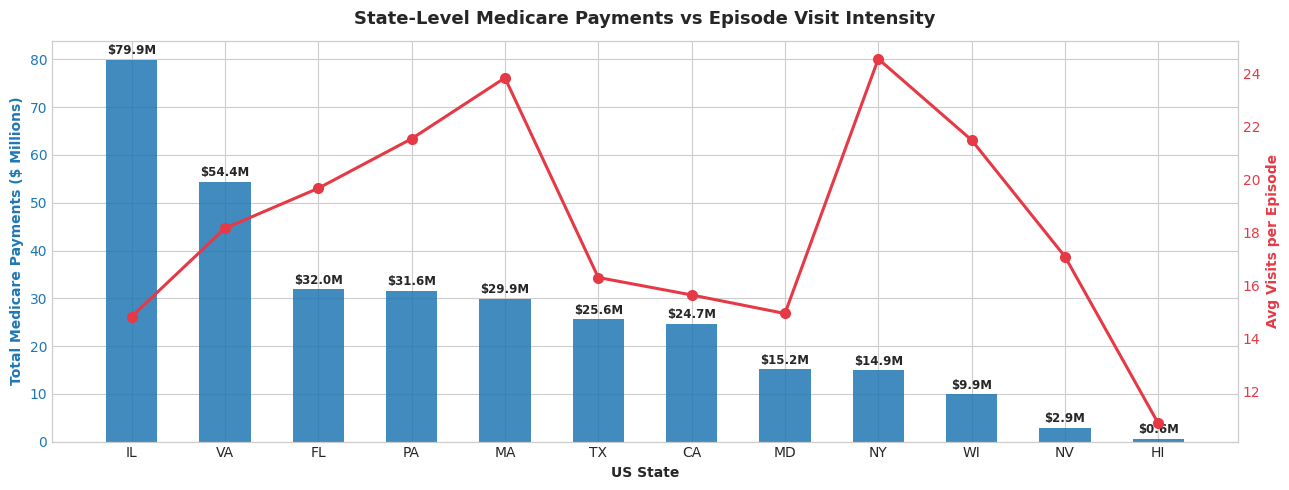

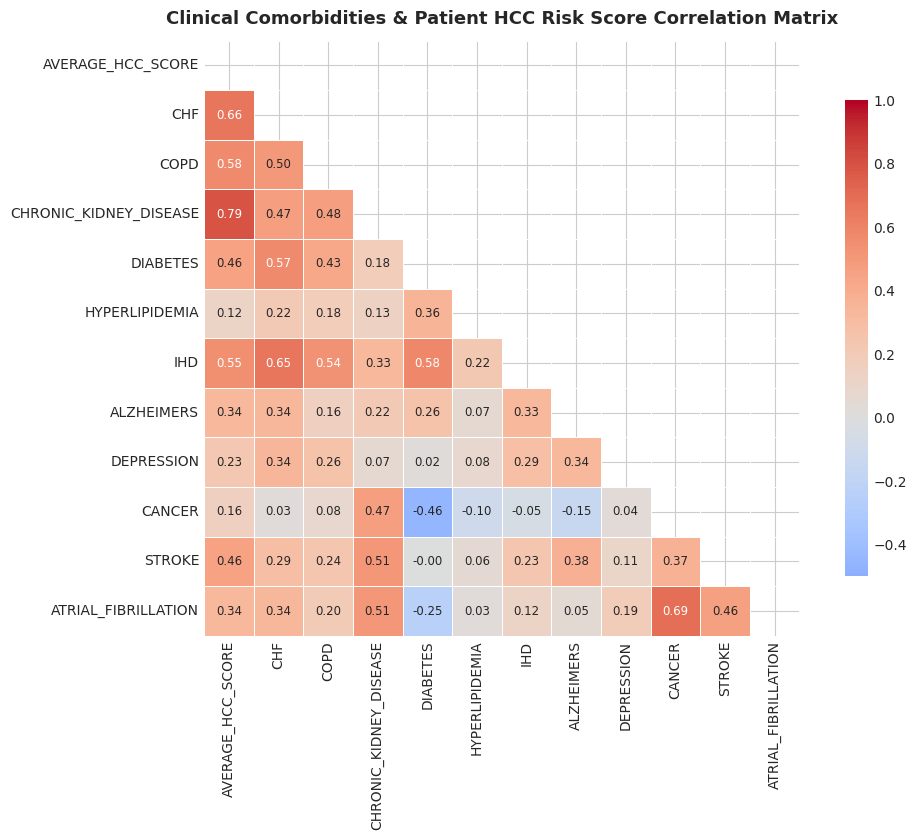

In [10]:
# 1. State Revenue vs Visit Intensity Dual-Axis Chart
state_agg = df.groupby('state').agg({
    'total_hha_medicare_payment_amount_non_lupa': 'sum',
    'average_number_of_total_visits_per_episode_non_lupa': 'mean'
}).reset_index().sort_values(by='total_hha_medicare_payment_amount_non_lupa', ascending=False)

fig, ax1 = plt.subplots(figsize=(13, 5))
color_bar = '#1f77b4'
ax1.set_xlabel('US State', fontweight='bold')
ax1.set_ylabel('Total Medicare Payments ($ Millions)', color=color_bar, fontweight='bold')
bars = ax1.bar(state_agg['state'], state_agg['total_hha_medicare_payment_amount_non_lupa'] / 1e6, color=color_bar, alpha=0.85, width=0.55)
ax1.tick_params(axis='y', labelcolor=color_bar)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"${yval:.1f}M", ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2 = ax1.twinx()
color_line = '#e63946'
ax2.set_ylabel('Avg Visits per Episode', color=color_line, fontweight='bold')
ax2.plot(state_agg['state'], state_agg['average_number_of_total_visits_per_episode_non_lupa'], color=color_line, marker='o', linewidth=2.2, markersize=7)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.grid(False)

plt.title('State-Level Medicare Payments vs Episode Visit Intensity', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# 2. Clinical Comorbidities & HCC Risk Correlation Matrix
clinical_subset = [
    'average_hcc_score', 'percent_of_beneficiaries_with_chf',
    'percent_of_beneficiaries_with_copd', 'percent_of_beneficiaries_with_chronic_kidney_disease',
    'percent_of_beneficiaries_with_diabetes', 'percent_of_beneficiaries_with_hyperlipidemia',
    'percent_of_beneficiaries_with_ihd', 'percent_of_beneficiaries_with_alzheimers',
    'percent_of_beneficiaries_with_depression', 'percent_of_beneficiaries_with_cancer',
    'percent_of_beneficiaries_with_stroke', 'percent_of_beneficiaries_with_atrial_fibrillation'
]
corr_df = df[clinical_subset].copy()
corr_df.columns = [c.replace('percent_of_beneficiaries_with_', '').upper() for c in corr_df.columns]
corr_mat = corr_df.corr()

fig, ax = plt.subplots(figsize=(11, 8.5))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, cmap='coolwarm', vmax=1.0, vmin=-0.5, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, annot=True, fmt='.2f', annot_kws={"size": 8.5}, ax=ax)
plt.title('Clinical Comorbidities & Patient HCC Risk Score Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### 2.6 Inferential Statistics & Hypothesis Testing
We perform two-tailed hypothesis tests to establish statistical significance:
1. **Welch's Two-Sample Independent t-Test:** Comparing Episode Payment in High-Acuity ($HCC > 2.2$) vs Moderate/Low Acuity agencies.
2. **Kruskal-Wallis Non-Parametric ANOVA:** Testing whether Visit Intensity varies significantly across US Census Regions.
3. **Pearson & Spearman Correlation:** Assessing the relationship between Dual Eligibility and Clinical Acuity.


In [11]:
# 1. Welch's t-test
high_hcc_pmt = df[df['average_hcc_score'] > 2.20]['payment_per_episode'].dropna()
low_hcc_pmt = df[df['average_hcc_score'] <= 2.20]['payment_per_episode'].dropna()
t_stat, p_val_t = stats.ttest_ind(high_hcc_pmt, low_hcc_pmt, equal_var=False)

print("=" * 80)
print("📌 STATISTICAL TEST 1: Welch's Two-Sample t-Test (Payment per Episode by HCC Acuity)")
print(f"High Acuity Mean: ${high_hcc_pmt.mean():,.2f} | Low Acuity Mean: ${low_hcc_pmt.mean():,.2f}")
print(f"t-statistic: {t_stat:.4f} | p-value: {p_val_t:.4e}")

# 2. Kruskal-Wallis Test
region_visits = [grp['average_number_of_total_visits_per_episode_non_lupa'].values for _, grp in df.groupby('region') if len(grp) >= 2]
kw_stat, p_val_kw = stats.kruskal(*region_visits)

print("\n" + "=" * 80)
print("📌 STATISTICAL TEST 2: Kruskal-Wallis Test (Visit Intensity across Geographic Regions)")
print(f"H-statistic: {kw_stat:.4f} | p-value: {p_val_kw:.4e}")
if p_val_kw < 0.05:
    print("✅ Result: Statistically significant variation across US Regions (p < 0.05)")

# 3. Pearson Correlation
r_pearson, p_pearson = stats.pearsonr(df['pct_dual_eligible'], df['average_hcc_score'])
print("\n" + "=" * 80)
print("📌 STATISTICAL TEST 3: Correlation (Dual Eligibility vs Patient HCC Acuity)")
print(f"Pearson r: {r_pearson:.4f} | p-value: {p_pearson:.4e}")
print("=" * 80)


📌 STATISTICAL TEST 1: Welch's Two-Sample t-Test (Payment per Episode by HCC Acuity)
High Acuity Mean: $3,150.15 | Low Acuity Mean: $3,102.62
t-statistic: 0.4337 | p-value: 6.6570e-01

📌 STATISTICAL TEST 2: Kruskal-Wallis Test (Visit Intensity across Geographic Regions)
H-statistic: 18.2654 | p-value: 3.8774e-04
✅ Result: Statistically significant variation across US Regions (p < 0.05)

📌 STATISTICAL TEST 3: Correlation (Dual Eligibility vs Patient HCC Acuity)
Pearson r: 0.1564 | p-value: 1.6060e-01


---
# 🔴 LEVEL 3: INTERMEDIATE-TO-ADVANCED DATA SCIENCE & STRATEGY
*Predictive Linear Regression, Unsupervised K-Means Clustering, PCA Dimensionality Reduction & Isolation Forest Anomaly Detection*
---


### 3.1 Multi-Variable Linear Regression for Payment Forecasting
We build an OLS Linear Regression model to quantify the contribution of episode volume, visit intensity, patient risk score, outlier payment %, and dual eligibility toward Total Medicare Reimbursement.


In [12]:
features_reg = [
    'total_episodes_non_lupa',
    'average_number_of_total_visits_per_episode_non_lupa',
    'average_hcc_score',
    'outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa',
    'pct_dual_eligible',
    'average_age'
]

X = df[features_reg].fillna(0)
y = df['total_hha_medicare_payment_amount_non_lupa']

reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

coef_table = pd.DataFrame({
    'Feature': features_reg,
    'Coefficient ($)': reg.coef_,
    'Abs_Importance': np.abs(reg.coef_)
}).sort_values(by='Abs_Importance', ascending=False)

print("🎯 MULTI-VARIABLE LINEAR REGRESSION RESULTS:")
print(f"R² (Variance Explained): {r2:.4f} ({r2*100:.2f}%)")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print("-" * 60)
display(coef_table)


🎯 MULTI-VARIABLE LINEAR REGRESSION RESULTS:
R² (Variance Explained): 0.9803 (98.03%)
Mean Absolute Error (MAE): $411,811.04
Root Mean Squared Error (RMSE): $560,854.07
------------------------------------------------------------


,Feature,Coefficient ($),Abs_Importance
1,average_number_of_total_visits_per_episode_non...,"94,630.95","94,630.95"
2,average_hcc_score,"33,103.21","33,103.21"
5,average_age,"25,103.27","25,103.27"
3,outlier_payments_as_a_percent_of_medicare_paym...,"-22,682.23","22,682.23"
0,total_episodes_non_lupa,"3,339.06","3,339.06"
4,pct_dual_eligible,590.99,590.99


### 3.2 Unsupervised K-Means Provider Segmentation & PCA
We segment providers into 3 operational practice archetypes using K-Means clustering and visualize them in 2D space using Principal Component Analysis (PCA).


🎯 PROVIDER PRACTICE ARCHETYPES CENTROID PROFILE:


,total_episodes_non_lupa,average_number_of_total_visits_per_episode_non_lupa,pct_skilled_nursing_visits,pct_therapy_visits_combined,pct_aide_visits,payment_per_episode,average_hcc_score,outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa,pct_dual_eligible
provider_archetype,,,,,,,,,
Archetype 1: High-Therapy Rehabilitation,"1,811.37",17.56,35.51,58.71,5.90,"3,465.68",2.00,0.29,24.83
Archetype 2: High-Acuity Complex Outlier,"1,115.29",23.18,54.52,22.75,22.75,"3,342.93",2.45,5.63,53.20
Archetype 3: Standard Routine Nursing,775.08,14.11,65.83,24.72,9.47,"2,773.73",2.19,1.24,64.00


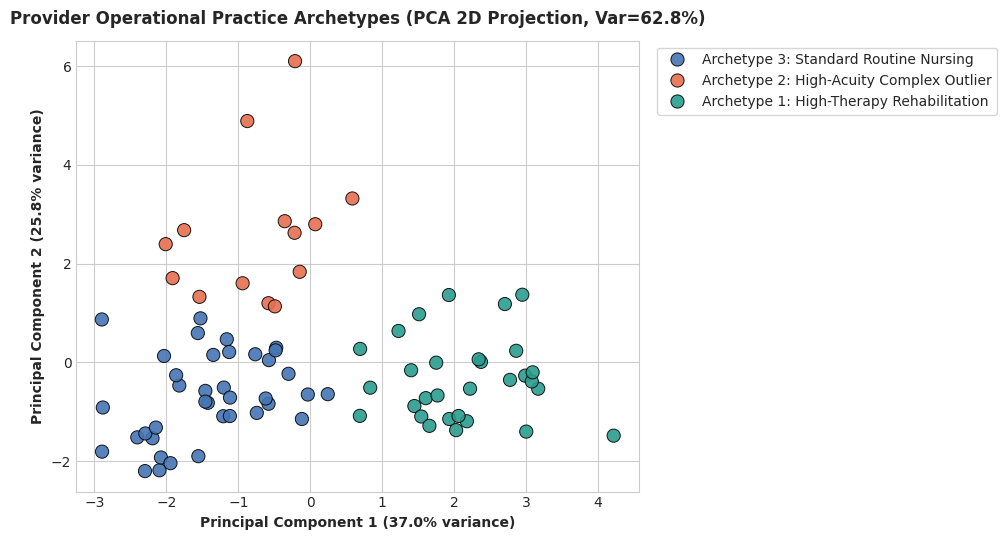

In [13]:
cluster_feats = [
    'total_episodes_non_lupa',
    'average_number_of_total_visits_per_episode_non_lupa',
    'pct_skilled_nursing_visits',
    'pct_therapy_visits_combined',
    'pct_aide_visits',
    'payment_per_episode',
    'average_hcc_score',
    'outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa',
    'pct_dual_eligible'
]

X_cl = df[cluster_feats].fillna(0)
scaler = StandardScaler()
X_cl_scaled = scaler.fit_transform(X_cl)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=15)
df['cluster_id'] = kmeans.fit_predict(X_cl_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_cl_scaled)
df['pca_1'] = pca_coords[:, 0]
df['pca_2'] = pca_coords[:, 1]

# Profile centroids
cl_summary = df.groupby('cluster_id')[cluster_feats].mean()

archetypes = {}
for c in range(3):
    row = cl_summary.loc[c]
    if row['pct_therapy_visits_combined'] >= 45:
        archetypes[c] = 'Archetype 1: High-Therapy Rehabilitation'
    elif row['outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa'] >= 4.0 or row['average_hcc_score'] >= 2.35:
        archetypes[c] = 'Archetype 2: High-Acuity Complex Outlier'
    else:
        archetypes[c] = 'Archetype 3: Standard Routine Nursing'
df['provider_archetype'] = df['cluster_id'].map(archetypes)

print("🎯 PROVIDER PRACTICE ARCHETYPES CENTROID PROFILE:")
display(df.groupby('provider_archetype')[cluster_feats].mean())

# Plot PCA Scatter
fig, ax = plt.subplots(figsize=(10, 5.5))
palette = {'Archetype 1: High-Therapy Rehabilitation': '#2a9d8f', 'Archetype 2: High-Acuity Complex Outlier': '#e76f51', 'Archetype 3: Standard Routine Nursing': '#4575b4'}

sns.scatterplot(
    data=df, x='pca_1', y='pca_2', hue='provider_archetype', palette=palette,
    s=90, alpha=0.9, edgecolor='black', linewidth=0.7, ax=ax
)
plt.title(f'Provider Operational Practice Archetypes (PCA 2D Projection, Var={pca.explained_variance_ratio_.sum()*100:.1f}%)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontweight='bold')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


### 3.3 Isolation Forest Anomaly Detection (Compliance Audit)
To detect aberrant billing and utilization patterns, we train an unsupervised **Isolation Forest** anomaly detector to flag potential compliance audit risks.


In [14]:
anom_features = [
    'payment_to_charge_ratio',
    'charge_to_payment_markup',
    'payment_per_episode',
    'outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa',
    'average_number_of_total_visits_per_episode_non_lupa',
    'lupa_episode_rate'
]

X_an = df[anom_features].fillna(0)
X_an_sc = scaler.fit_transform(X_an)

iso = IsolationForest(contamination=0.08, random_state=42)
df['audit_flag'] = np.where(iso.fit_predict(X_an_sc) == -1, 'Potential Audit Flag', 'Standard Pattern')
df['anomaly_score'] = iso.decision_function(X_an_sc)

flagged = df[df['audit_flag'] == 'Potential Audit Flag'][[
    'provider_id', 'agency_name', 'state', 'total_episodes_non_lupa',
    'payment_per_episode', 'charge_to_payment_markup', 'outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa',
    'lupa_episode_rate', 'average_number_of_total_visits_per_episode_non_lupa', 'anomaly_score'
]].sort_values(by='anomaly_score')

print(f"🚨 ISOLATION FOREST FLAGGED {len(flagged)} AGENCIES FOR COMPLIANCE AUDIT:")
display(flagged)


🚨 ISOLATION FOREST FLAGGED 7 AGENCIES FOR COMPLIANCE AUDIT:


,provider_id,agency_name,state,total_episodes_non_lupa,payment_per_episode,charge_to_payment_markup,outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa,lupa_episode_rate,average_number_of_total_visits_per_episode_non_lupa,anomaly_score
8,557523,MERCY HOME CARE,CA,419,"3,016.79",2.17,0.0000,17.52,12.60,-0.09
46,337290,"AMERICARE CERTIFIED SPECIAL SERVICES, INC CHHA",NY,3083,"4,216.66",0.92,9.20,10.06,32.40,-0.07
10,59118,"MEDQUEST HEALTH SERVICES, INC",CA,441,"2,998.22",0.44,0.10,6.37,8.80,-0.05
70,127025,PRIME CARE SERVICES HAWAII INC,HI,171,"3,345.60",0.53,0.0000,20.83,10.80,-0.03
67,527083,HORIZON HOME CARE AND HOSPICE,WI,3062,"3,242.47",1.20,9.00,21.43,21.50,-0.03
3,227290,"SUBURBAN HOME HEALTH CARE, INC",MA,1466,"3,785.58",1.06,8.80,3.81,31.90,-0.03
47,337425,"PREMIER HOME HEALTH CARE SERVICES, INC",NY,178,"3,388.76",0.93,6.70,23.93,17.40,-0.0022


### 3.4 Master Executive KPI Scorecard & Strategic Recommendations


In [15]:
kpi_summary = pd.DataFrame({
    'Metric Category': [
        'Network Scale', 'Network Scale', 'Episode Volume', 'Episode Volume',
        'Financial Performance', 'Financial Performance', 'Financial Performance', 'Financial Performance',
        'Clinical & Risk Acuity', 'Clinical & Risk Acuity', 'Clinical & Risk Acuity',
        'Service Delivery Mix', 'Service Delivery Mix', 'Service Delivery Mix',
        'Vulnerable Populations', 'Vulnerable Populations'
    ],
    'Executive KPI': [
        'Total Certified Agencies', 'Total Geographic States Represented',
        'Total Non-LUPA Episodes Delivered', 'Total Distinct Beneficiaries Served',
        'Total Medicare Actual Payments', 'Total Billed Charges',
        'Average Reimbursement per Episode', 'Average Charge-to-Payment Markup Ratio',
        'Mean Patient HCC Risk Score', 'High Acuity Tier 3 Agency Share', 'Average Outlier Payment %',
        'Average Skilled Nursing Visit Share', 'Average Combined Therapy Visit Share', 'Average Home Health Aide Visit Share',
        'Average Dual-Eligible Beneficiary %', 'Average Beneficiary Age'
    ],
    'Observed Value': [
        f"{df['provider_id'].nunique():,}",
        f"{df['state'].nunique():,}",
        f"{df['total_episodes_non_lupa'].sum():,}",
        f"{df['distinct_beneficiaries_non_lupa'].sum():,}",
        f"${df['total_hha_medicare_payment_amount_non_lupa'].sum():,}",
        f"${df['total_hha_charge_amount_non_lupa'].sum():,}",
        f"${df['payment_per_episode'].mean():,.2f}",
        f"{df['charge_to_payment_markup'].mean():.2f}x",
        f"{df['average_hcc_score'].mean():.2f}",
        f"{(df['hcc_risk_tier'] == 'Tier 3: High Acuity (>2.40)').mean()*100:.1f}%",
        f"{df['outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa'].mean():.2f}%",
        f"{df['pct_skilled_nursing_visits'].mean():.1f}%",
        f"{df['pct_therapy_visits_combined'].mean():.1f}%",
        f"{df['pct_aide_visits'].mean():.1f}%",
        f"{df['pct_dual_eligible'].mean():.1f}%",
        f"{df['average_age'].mean():.1f} years"
    ]
})

print("🏆 MASTER HEALTHCARE EXECUTIVE KPI SCORECARD:")
display(kpi_summary)


🏆 MASTER HEALTHCARE EXECUTIVE KPI SCORECARD:


,Metric Category,Executive KPI,Observed Value
0,Network Scale,Total Certified Agencies,82
1,Network Scale,Total Geographic States Represented,12
2,Episode Volume,Total Non-LUPA Episodes Delivered,"99,408"
3,Episode Volume,Total Distinct Beneficiaries Served,"59,399"
4,Financial Performance,Total Medicare Actual Payments,"$321,600,795"
5,Financial Performance,Total Billed Charges,"$306,434,526"
6,Financial Performance,Average Reimbursement per Episode,"$3,124.07"
7,Financial Performance,Average Charge-to-Payment Markup Ratio,0.91x
8,Clinical & Risk Acuity,Mean Patient HCC Risk Score,2.16
9,Clinical & Risk Acuity,High Acuity Tier 3 Agency Share,25.6%


---

## 💡 Strategic Takeaways for Healthcare Executives & Data Analysts

1. **LUPA Mitigation Strategy:** Monitoring visit completion schedules prevents premature episode closure, protecting agencies from losing $2,000+ per episode under per-visit LUPA penalties.
2. **Wage Index Impact:** Geographic labor price differences create substantial variance between actual and standardized reimbursement. Payers and health system leaders must account for regional wage index adjustments when modeling acquisitions or setting care budgets.
3. **Audit Readiness for Outlier Reimbursement:** Agencies with outlier payments $>5.0\%$ must ensure clinical documentation explicitly defends the necessity of extended care visit frequencies against CMS Recovery Audit Contractors (RAC).
4. **Health Equity Interventions:** Dual-eligible beneficiaries experience elevated depression ($>40\%$) and chronic heart failure burden, warranting dedicated medical social work and care coordination programs to avert costly hospital readmissions.

---
### 🎓 Project Conclusion
This project demonstrates the complete lifecycle of a Healthcare Data Analyst — from **Basic Data Ingestion & SQL Queries** to **Intermediate Relational Modeling & Statistics**, through **Advanced Machine Learning & Business Intelligence**.
